In [1]:
 !pip install pandas

In [4]:
!pip install matplotlib

In [3]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [15 lines of output]
  The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
  rather than 'sklearn' for pip commands.
  
  Here is how to fix this error in the main use cases:
  - use 'pip install scikit-learn' rather than 'pip install sklearn'
  - replace 'sklearn' by 'scikit-learn' in your pip requirements files
    (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
  - if the 'sklearn' package is used by one of your dependencies,
    it would be great if you take some time to track which package uses
    'sklearn' instead of 'scikit-learn' and report it to their issue tracker
  - as a last resort, set the environment variable
    SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
  
  More information is available at
  https://github.com/scikit-learn/sklearn-pypi-package
  [end of output]
  
  note: This error originates f

In [6]:
import pandas as pd
from matplotlib import pyplot as plt

In [10]:
df = pd.read_csv('nasdaq100.csv', sep=';')

In [11]:
df.head()

,Date,Starting (USD),Ending (USD)
0,01.01.24,16800,16500
1,01.12.23,15900,16100
2,01.11.23,15800,15300
3,01.10.23,16100,16200
4,01.09.23,16300,15700


In [12]:
df.isnull().sum()

Date              0
Starting (USD)    0
Ending (USD)      0
dtype: int64

In [21]:
#we wont work with date then
#df = df.drop(columns=['Date'])
df.drop('Date',axis=1)

KeyError: "['Date'] not found in axis"

In [22]:
df.head()

,Starting (USD),Ending (USD)
0,16800,16500
1,15900,16100
2,15800,15300
3,16100,16200
4,16300,15700


Text(0.5, 1.0, 'NASDAQ100 Stock prices')

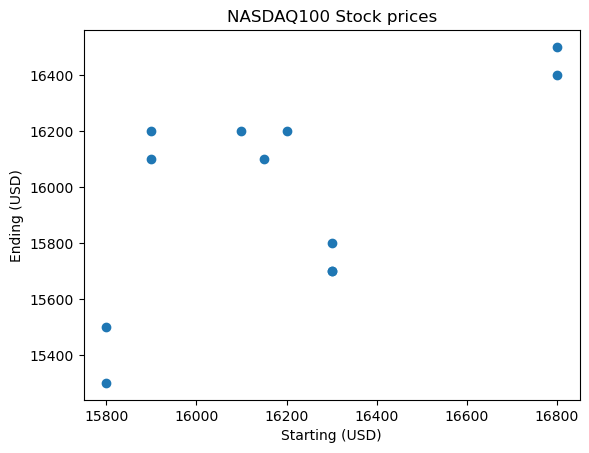

In [23]:
plt.scatter(df['Starting (USD)'],df['Ending (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('NASDAQ100 Stock prices')

Text(0.5, 1.0, 'NASDAQ100 Stock prices')

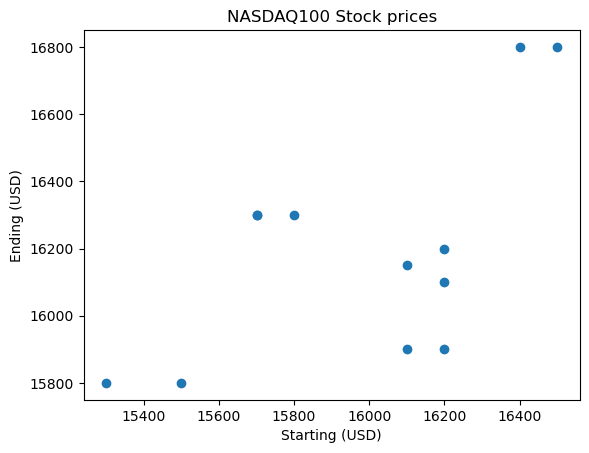

In [24]:
plt.scatter(df['Ending (USD)'],df['Starting (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('NASDAQ100 Stock prices')

Text(0.5, 1.0, 'NASDAQ100 Stock prices')

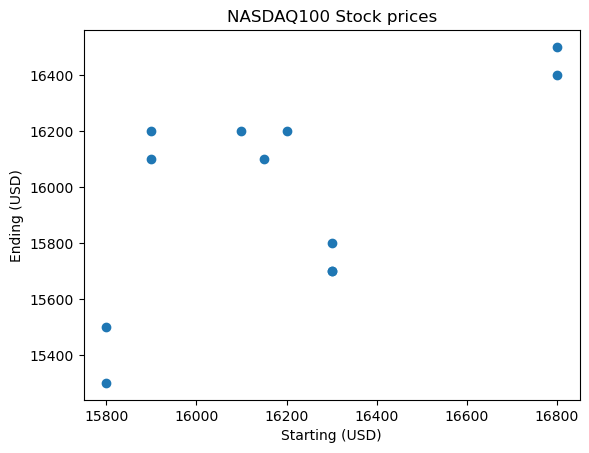

In [25]:
plt.scatter(df['Starting (USD)'],df['Ending (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('NASDAQ100 Stock prices')

In [26]:
x= df.drop('Ending (USD)',axis=1)

In [27]:
x.head()

,Starting (USD)
0,16800
1,15900
2,15800
3,16100
4,16300


In [30]:
y=df['Ending (USD)']
y.head()

0    16500
1    16100
2    15300
3    16200
4    15700
Name: Ending (USD), dtype: int64

In [33]:
y=df[['Ending (USD)']]
y.head()

,Ending (USD)
0,16500
1,16100
2,15300
3,16200
4,15700


Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression 

In [36]:
reg = LinearRegression()

In [37]:
x.mean()

Starting (USD)    16195.833333
dtype: float64

In [38]:
y.mean()

Ending (USD)    15975.0
dtype: float64

Text(0.5, 1.0, 'NASDAQ100 Stock prices')

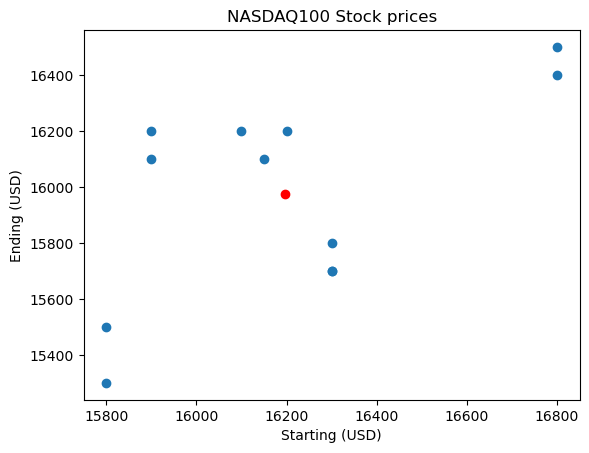

In [42]:
plt.scatter(x.mean() , y.mean(), color= 'red')
plt.scatter(df['Starting (USD)'],df['Ending (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('NASDAQ100 Stock prices')

In [43]:
reg.fit(x,y) #train the model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:

m=reg.coef_

In [56]:
c=reg.intercept_

In [57]:
#y=mx+c
m*16700 + c

array([[16304.0105628]])

In [60]:
reg.predict([[16700]])

D:\Python Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[16304.0105628]])

In [64]:
df['Predicted_y'] = reg.predict(x)
df.head()

,Starting (USD),Ending (USD),Predicted_y
0,16800,16500,16369.268856
1,15900,16100,15781.944215
2,15800,15300,15716.685922
3,16100,16200,15912.460802
4,16300,15700,16042.977389


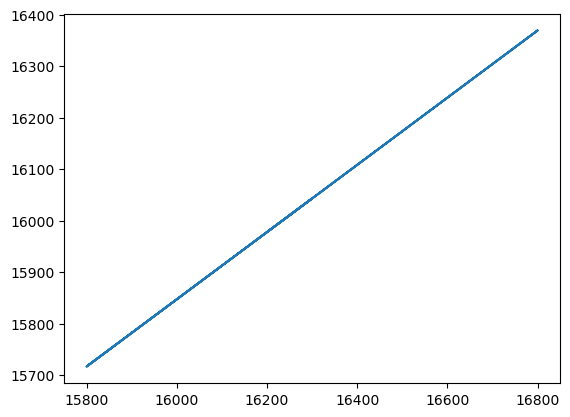

In [67]:
 plt.plot(x,reg.predict(x))

Text(0.5, 1.0, 'NASDAQ100 Stock prices')

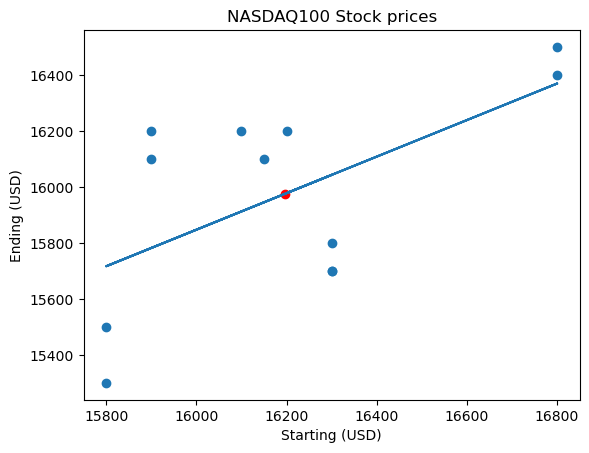

In [69]:
plt.plot(x,reg.predict(x))
plt.scatter(x.mean() , y.mean(), color= 'red')
plt.scatter(df['Starting (USD)'],df['Ending (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('NASDAQ100 Stock prices')

Lose and cost function 

In [72]:
df['lose'] = df['Ending (USD)']-df['Predicted_y']

In [73]:
df.head()

,Starting (USD),Ending (USD),Predicted_y,lose
0,16800,16500,16369.268856,130.731144
1,15900,16100,15781.944215,318.055785
2,15800,15300,15716.685922,-416.685922
3,16100,16200,15912.460802,287.539198
4,16300,15700,16042.977389,-342.977389


In [86]:
#MSE for linear regrssion and MAE
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [89]:
mse = mean_squared_error(df['Ending (USD)'],df['Predicted_y'])
mse

80411.23397700385

In [90]:
mae = mean_absolute_error(df['Ending (USD)'],df['Predicted_y'])
mae

260.3840017604666

In [92]:
abs(df['lose'])

0     130.731144
1     318.055785
2     416.685922
3     287.539198
4     342.977389
5      30.731144
6     418.055785
7     216.685922
8     154.910051
9     242.977389
10    222.280904
11    342.977389
Name: lose, dtype: float64

In [93]:
sum(abs(df['lose']))/len(x)

260.3840017604666

In [95]:
reg.score(x,y)

0.3577804940272571

Text(0.5, 1.0, 'NASDAQ100 Stock prices')

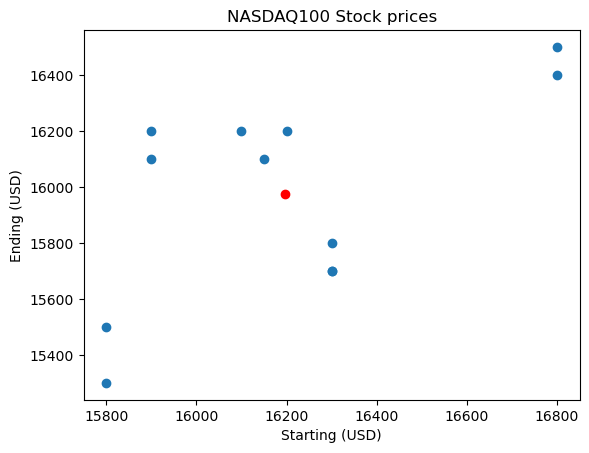

In [96]:
plt.scatter(x.mean() , y.mean(), color= 'red')
plt.scatter(df['Starting (USD)'],df['Ending (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('NASDAQ100 Stock prices')

Text(0.5, 1.0, 'NASDAQ100 Stock prices')

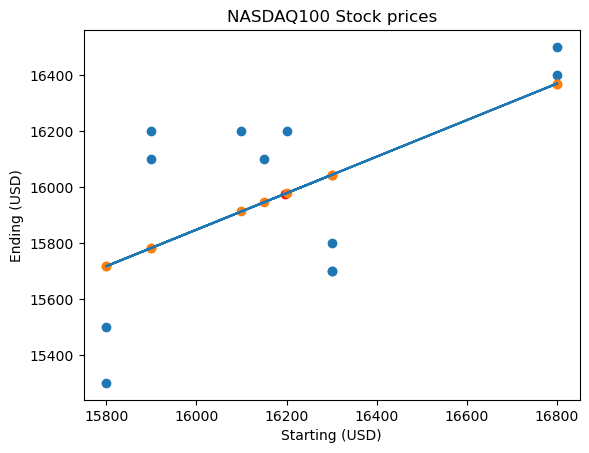

In [99]:
plt.plot(x,reg.predict(x))
plt.scatter(x.mean() , y.mean(), color= 'red')
plt.scatter(df['Starting (USD)'],df['Ending (USD)'])
plt.scatter(df['Starting (USD)'],reg.predict(x))
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('NASDAQ100 Stock prices')

In [100]:
reg.score(x,y)

0.3577804940272571

In [102]:
from sklearn.metrics import r2_score
r2_score(y, reg.predict(x))

0.3577804940272571